In [9]:
# DSN Second assignment
import pandas as pd
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"



In [11]:
#Read the CSV
df=pd.read_csv(url)

In [12]:
#Preview the first row
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
#Check the datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [15]:
#Null values in each columns 
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [21]:
# Find the most common boarding port
most_common_port= df['Embarked'].mode()[0]
print(f" Most common port:{most_common_port}")

 Most common port:S


In [22]:
# Fill the missing values with it
df['Embarked']=df['Embarked'].fillna(most_common_port)

In [26]:
# Calculate the median age
median_age = df['Age'].median()
print(f"Median age:{median_age}")

Median age:28.0


In [27]:
# Fill the missing ages
df['Age']=df['Age'].fillna(median_age)

In [28]:
# If cabin is known, 0 if is NAN
df['Has_Cabin']=df['Cabin'].notnull().astype(int)

In [29]:
# Drop the original messy cabin
df=df.drop(columns=['Cabin'])

In [30]:
#Verify the fix
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


In [31]:
most_common_port=df['Embarked'].mode()[0]
print(f"Most common port:{most_common_port}")

Most common port:S


In [33]:
#Exploratory Analysis
import matplotlib.pyplot as plt
import seaborn as sns
#1. Set up a clean grid styles 
sns.set_theme(style="whitegrid")

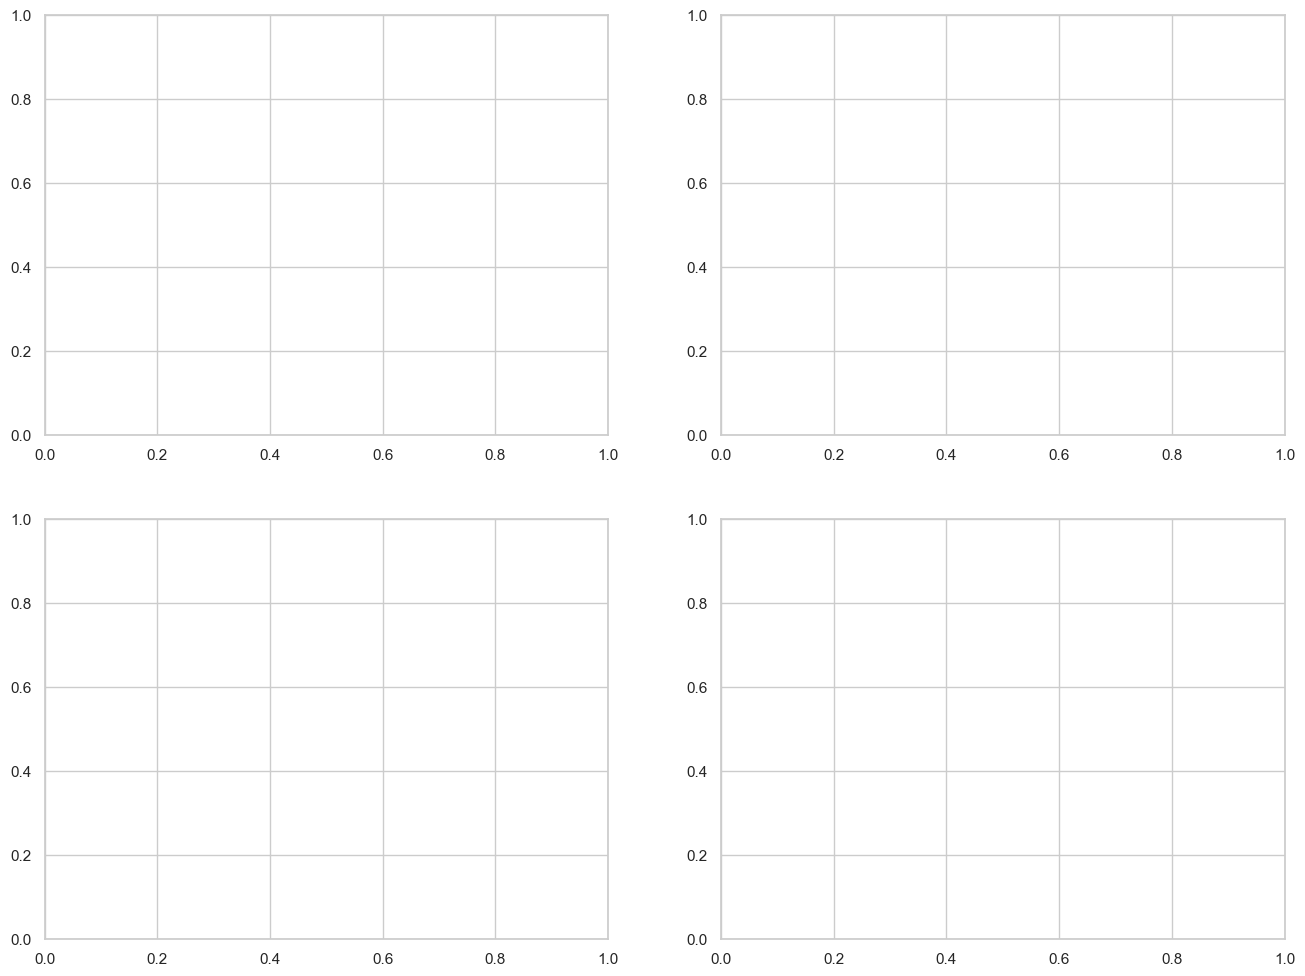

In [34]:
#Create a 2 X 2 grid layout for our dashboard
fig,axes=plt.subplots(2,2, figsize=(16,12))

In [38]:
# Overall survival
sns.countplot(x='Survived',data=df,
ax=axes[0,0])
axes[0,0].set_title('Overall count of survivors(0=Died,1= Survived)')


Text(0.5, 1.0, 'Overall count of survivors(0=Died,1= Survived)')

In [48]:
# Survival by Gender
sns.countplot(x='Survived',hue='Sex', data=df, ax=axes[0,1])
ax=axes[0,1].set_title('Survival Count Split by Gender')


In [40]:
# Survival by Passenger Class
sns.barplot(x='Pclass',y='Survived', data=df,
ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Passenger Class')
axes[1,0].set_ylabel('proportion Survived')

Text(4.444444444444459, 0.5, 'proportion Survived')

In [44]:
#Age Distribution of Survivors vs Non -Survivors
sns.kdeplot(data=df, x='Age',
hue='Survived',fill=True,
common_norm = False, alpha = 0.5,
ax = axes [1,1])
axes[1,1].set_title('Age Distribution:Survivors vs. Non-Surviors')

Text(0.5, 1.0, 'Age Distribution:Survivors vs. Non-Surviors')

In [46]:
# Clean up the layout
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

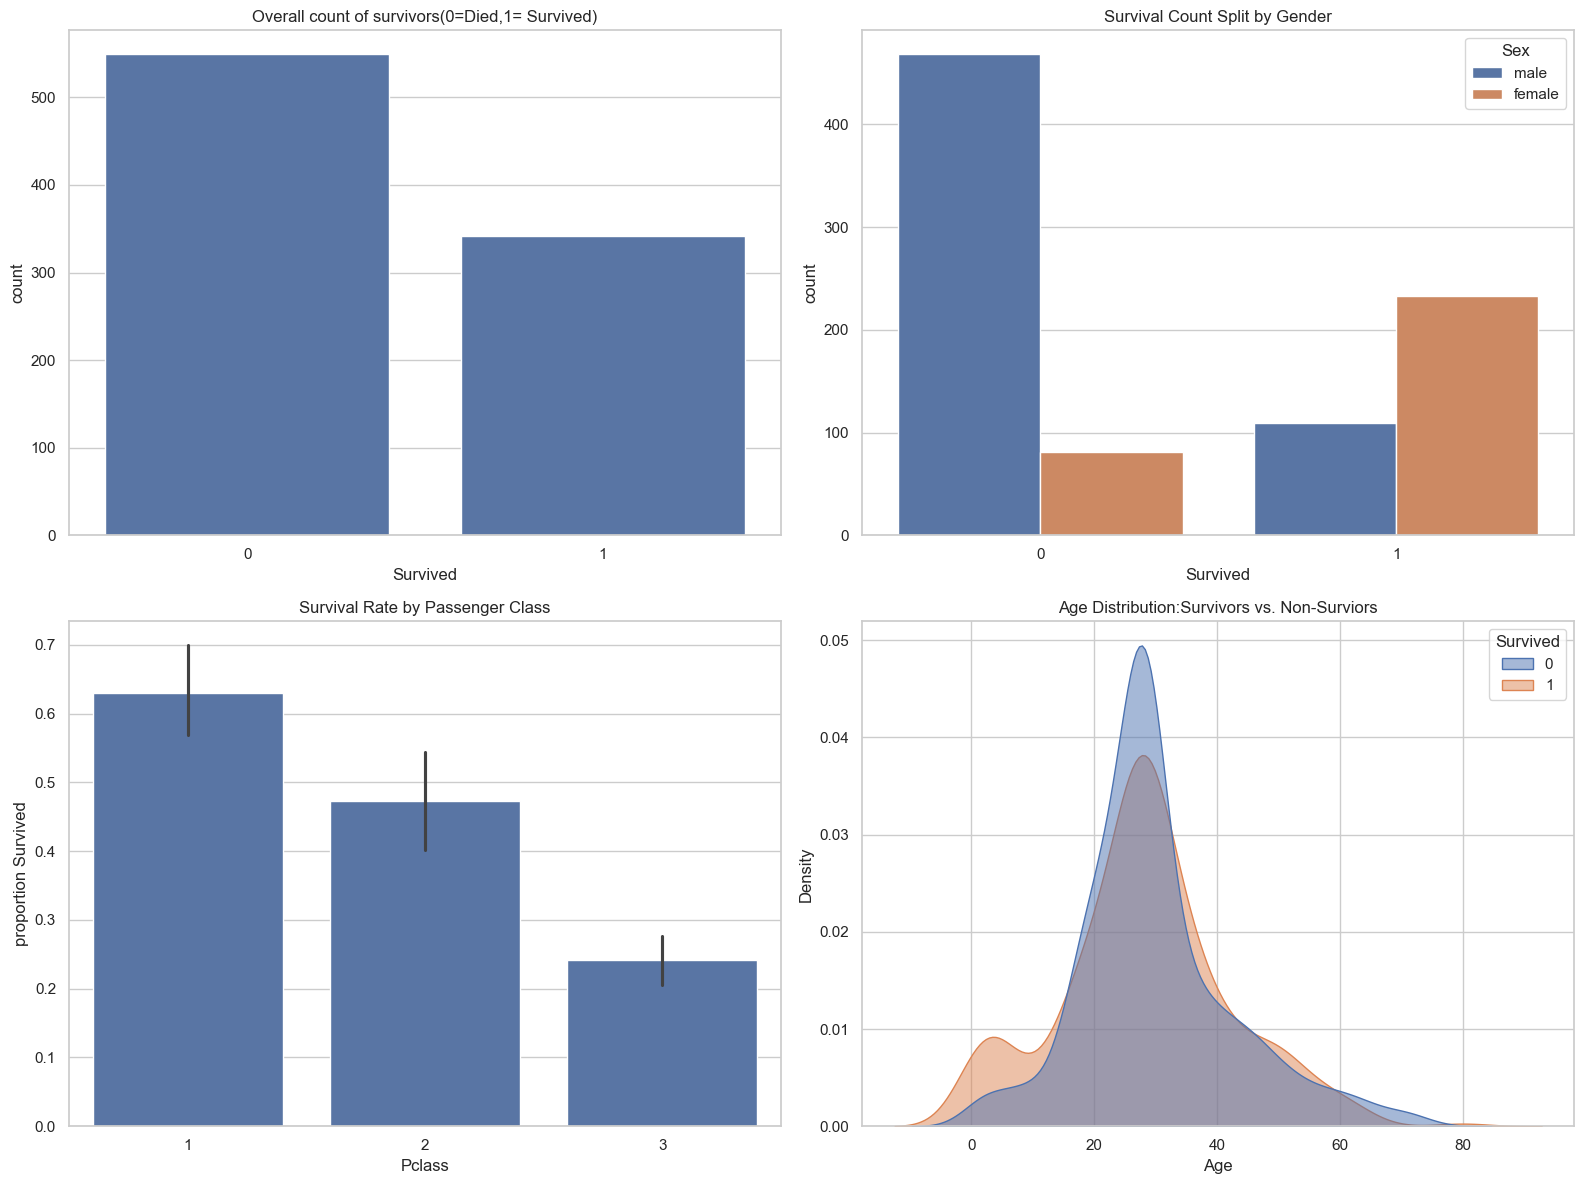

In [51]:
sns.set_theme(style="whitegrid")
fig,axes=plt.subplots(2,2, figsize=(16,12))
sns.countplot(x='Survived',data=df,
ax=axes[0,0])
axes[0,0].set_title('Overall count of survivors(0=Died,1= Survived)')
sns.countplot(x='Survived',hue='Sex', data=df, ax=axes[0,1])
ax=axes[0,1].set_title('Survival Count Split by Gender')
sns.barplot(x='Pclass',y='Survived', data=df,
ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Passenger Class')
axes[1,0].set_ylabel('proportion Survived')
sns.kdeplot(data=df, x='Age',
hue='Survived',fill=True,
common_norm = False, alpha = 0.5,
ax = axes [1,1])
axes[1,1].set_title('Age Distribution:Survivors vs. Non-Surviors')
plt.tight_layout()
plt.show()
